In [29]:
import pandas as pd
from pathlib import Path
import json
from getpass import getpass
from langchain_text_splitters import RecursiveCharacterTextSplitter
from mistral_common.tokens.tokenizers.mistral import MistralTokenizer
from langchain_core.documents import Document
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings
import matplotlib.pyplot as plt
import os

In [2]:
DATA_DIR = Path("data")
STATS_DIR = Path("stats")

In [3]:
most_recent_file = max(
    (f for f in STATS_DIR.iterdir() if f.suffix == ".json"),
    key=lambda f: f.stat().st_mtime
)

with open(most_recent_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# idee: ajouter au debut de chaque chunk titre + description (cat = summary)

In [4]:
summaries = [content for content, metadata_dict in data.items() if metadata_dict.get("cat") == "summary"]

In [5]:
# FIXME : utiliser tokenizer du LLM ou rester en "mots" puisque LLM pas definitif pour le moment ?

# https://docs.langchain.com/oss/python/integrations/splitters/split_by_token
# https://huggingface.co/mistralai/Mistral-Small-3.2-24B-Instruct-2506

def count_nb_tokens(text):
    model_id = "mistralai/Mistral-Small-3.2-24B-Instruct-2506"
    tokenizer = MistralTokenizer.from_hf_hub(model_id)
    return len(tokenizer.instruct_tokenizer.tokenizer.encode(text, bos=False, eos=False))

df_summary_token_count = pd.DataFrame(summaries, columns=["summary"])
df_summary_token_count["token_count"] = df_summary_token_count["summary"].apply(count_nb_tokens)

In [6]:
# FIXME / TODO : montrer au prof
# FIXME : approximation des mots pour des tokens ok ou completement ko ? -> nb mots = 70% de nb tokens en moyenne donc ko ?

df_summary_token_count["word_count"] = df_summary_token_count["summary"].apply(lambda x: len(x.split()))
df_summary_token_count["ration_words_tokens"] = df_summary_token_count["word_count"] / df_summary_token_count["token_count"]
df_summary_token_count["char_count"] = df_summary_token_count["summary"].apply(len)

df_summary_token_count

,summary,token_count,word_count,ration_words_tokens,char_count
0,Loi fédérale sur les écoles polytechniques féd...,76,52,0.684211,366
1,Federal Act on the Federal Institutes of Techn...,60,52,0.866667,353
2,Ordonnance sur le domaine des écoles polytechn...,33,23,0.696970,150
3,Ordonnance sur le domaine des écoles polytechn...,30,21,0.700000,156
4,Ordonnance du Conseil des EPF sur les écoles p...,55,38,0.690909,219
...,...,...,...,...,...
331,Directive concernant la Commission du Personne...,98,75,0.765306,509
332,Directive concerning the Staff Commission of t...,86,66,0.767442,455
333,Ordonnance du Conseil des hautes écoles sur l’...,102,70,0.686275,499
334,Ordonnance du Conseil des hautes écoles sur l’...,87,64,0.735632,480


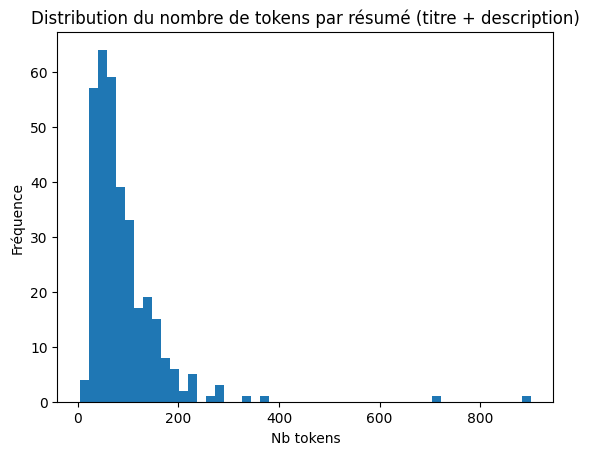

In [7]:
plt.hist(df_summary_token_count["token_count"], bins=50)
plt.xlabel("Nb tokens")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre de tokens par résumé (titre + description)")
plt.show()

In [8]:
# contrainte: taille du contenu trop important ?
# FIXME : quel est le pourcentage max a "assigner" a ce contenu dans un chunk ?
# FIXME : quelle est la taille max d'un chunk
# FIXME : depend de la taille de contexte du LLM mais aussi du nombre de chunks retrieved...
# FIXME : https://huggingface.co/mistralai/Mistral-Small-3.2-24B-Instruct-2506 -> 128K tokens pour input + output donc comment estimer la taille d'input idéale (+ mieux de faire "court" pour ne pas se perdre en chemin...)

# alternative: ajouter au debut de chaque chunk uniquement le titre et ne pas indexer du tout les "summary"

In [10]:
# TODO

from langchain_community.document_loaders import DirectoryLoader
from langchain_docling.loader import DoclingLoader
from langchain_community.document_loaders.parsers import TesseractBlobParser

# https://docs.langchain.com/oss/python/integrations/document_loaders/docling
# TODO : https://github.com/Arqamansari23/Advance-Doccuments-Processing-
# TODO : tester UnstructuredWordDocumentLoader (permet de conserver des éléments séparés avec mode="elements") -> https://docs.langchain.com/oss/python/integrations/document_loaders/unstructured_file
# TODO : tester PyMUPDF avec OCR https://docs.langchain.com/oss/python/integrations/document_loaders/pymupdf#extract-images-from-the-pdf-with-rapidocr

loaders = [
    #DirectoryLoader(DATA_DIR, glob="**/*.pdf", loader_cls=PyMuPDFLoader, loader_kwargs={"mode": "single", "images_parser": "TesseractBlobParser()", "images_inner_format": "text"}, show_progress=True), # TODO : ameliorer le loader
    DirectoryLoader(DATA_DIR, glob="**/*.pdf", loader_cls=DoclingLoader, show_progress=True),
    #DirectoryLoader(DATA_DIR, glob="**/*.txt", loader_cls=TextLoader, show_progress=True), TODO : a voir comment les traiter
    #DirectoryLoader(DATA_DIR, glob="**/*.docx", loader_cls=Docx2txtLoader, show_progress=True), TODO : cas particuliers, a analyser apres
]

In [11]:
docs = []
for loader in loaders:
    docs.extend(loader.load())

  0%|          | 0/320 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-04-01 14:23:51,742 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-01 14:23:51,749 [RapidOCR] download_file.py:60: File exists and is valid: /home/saskya/dev/tb/polylex-chatbot/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-04-01 14:23:51,750 [RapidOCR] main.py:53: Using /home/saskya/dev/tb/polylex-chatbot/.venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-04-01 14:23:51,894 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-01 14:23:51,896 [RapidOCR] download_file.py:60: File exists and is valid: /home/saskya/dev/tb/polylex-chatbot/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 

In [12]:
ARTICLE_PATTERN = r"\b(?:Article\s+\d+|Art\.\s+\d+)"

splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000, # TODO : comment definir (dans ce cas nb caracteres et pas tokens) ?
    chunk_overlap=300, # TODO : comment definir (dans ce cas nb caracteres et pas tokens) ?
    separators=[
        ARTICLE_PATTERN,
        "\n\n",
        "\n",
        " ",
        "",
    ],
    #length_function=count_nb_tokens, # TODO : si necessaire de compter en tokens alors modifier ici et modifier size + overlap
    is_separator_regex=True,
    add_start_index=True,
)

chunks = splitter.split_documents(docs)

In [15]:
# creation de dicts pour optimiser la recherche du titre pour chaque document
# TODO : comment gerer le mistmatch entre les langues (voir BZc4iYDbPh4FufpSQ dans json) ?
doc_id_to_lex_id = {}
lex_id_to_title = {}
for content, metadata_dict in data.items():
    ref = metadata_dict.get("refs")[0]
    lex_id = ref.get("lex_id")
    if metadata_dict.get("cat") == "summary":
        lex_id_to_title[lex_id] = content
    else:
        doc_id = metadata_dict.get("doc_id")
        doc_id_to_lex_id[doc_id] = lex_id

# ajout du titre du document au debut de chaque chunk
chunks_with_title = []
for chunk in chunks:
    path = chunk.metadata.get("source")
    doc_id = Path(path).stem
    lex_id = doc_id_to_lex_id.get(doc_id)
    summary = lex_id_to_title.get(lex_id) if lex_id else ""
    title = summary.split("\n")[0]

    page_content = f"Document: {title}\n{chunk.page_content}" if title else chunk.page_content

    chunks_with_title.append(
        Document(
            page_content=page_content,
            metadata=chunk.metadata # TODO : ajouter reference aux articles contenus dans ce chunk ?
        )
    )

In [17]:
# exemple de chunks avec Docling -> indexes dans
for i in range(0, 100):
    print("\n   ----------------------\n   ")
    print(f"SOURCE: {chunks_with_title[i].metadata.get("source")}\n")
    print(chunks_with_title[i].page_content)


   ----------------------
   
SOURCE: data/32f5618496692a491d692ff60dd08b33.pdf

Document: Ordinance of the École polytechnique fédérale de Lausanne on study grants
Ordonnance sur les bourses d'études
(Ordonnance de l'EPFL sur les bourses d'études)
du 2 août 2021 (État le 15 décembre 2025)
La Direction de l'École polytechnique fédérale de Lausanne, vu l'art. 25 de l'ordonnance du 13 novembre 2003 sur l'EPFZ et l'EPFL 1 , arrête:

   ----------------------
   
SOURCE: data/32f5618496692a491d692ff60dd08b33.pdf

Document: Ordinance of the École polytechnique fédérale de Lausanne on study grants
Art. 1 Objet
La  présente  ordonnance  réglemente  l'attribution  de  bourses  d'études  par  l'École polytechnique fédérale de Lausanne (EPFL).

   ----------------------
   
SOURCE: data/32f5618496692a491d692ff60dd08b33.pdf

Document: Ordinance of the École polytechnique fédérale de Lausanne on study grants
Art. 2 Bourses d'études
1 Les bourses d'études sont des prestations en espèces, uniques o

In [30]:
if not os.getenv("OPENAI_API_KEY_EMBEDDINGS"):
    os.environ["OPENAI_API_KEY_EMBEDDINGS"] = getpass("Enter your RCP API key for embedding model: ")

embeddings = OpenAIEmbeddings(
    model="Qwen/Qwen3-Embedding-8B",
    base_url="https://inference.rcp.epfl.ch/v1",
    api_key=os.getenv("OPENAI_API_KEY_EMBEDDINGS")
)

qdrant = QdrantVectorStore.from_documents(
    chunks_with_title,
    embeddings,
    url="http://localhost:6333",
    collection_name="RCTS_2000_300_article_docling"
)

In [24]:
for chunk in chunks_with_title:
    if chunk.metadata.get("source") == "data/f54bbb4bf5f9f0d25ad6799bb0660503.pdf":
        print(chunk.page_content)
        print("    -------------------------   ")
# FIXME : https://www.epfl.ch/about/overview/wp-content/uploads/2019/09/6.4.1.1_dir_recyclage_materiel_it_fr.pdf -> saute completement l'annexe 2 avec le graphique...

Document: Directive concerning the recycling and resale of IT equipment
Directive concernant la transmission, réutilisation et valorisation d'équipements IT LEX 6.4.1
Du 1 er  juin 2019, état au 15 janvier 2026
    -------------------------   
Document: Directive concerning the recycling and resale of IT equipment
La Direction de l'Ecole polytechnique fédérale de Lausanne
vu  l'art. 4, al. 1 de l'ordonnance sur l'organisation de l'Ecole polytec hnique fédérale de Lausanne, arrête :
    -------------------------   
Document: Directive concerning the recycling and resale of IT equipment
Article 1 But
- 1 Le but de cette directive est de préciser les règles et procédures de réutilisation et de revente d'équipements IT à l'EPFL, ainsi que les rôles et responsabilités des divers acteurs impliqués.
- 2 Cette directive et ses annexes s'applique nt à toutes les collaboratrices et collaborateurs et étudiantes et étudiants de l'EPFL.
    -------------------------   
Document: Directive concernin

In [127]:
# exemple de chunks -> FIXME : taille raisonnable ou trop petit ? -> si trop petit, essayer de tester un index avec chunk=1 page + chunk=eux ?
for i in range(0, len(chunks_with_title), 100):
    print("\n   ----------------------\n   ")
    print(f"SOURCE: {chunks_with_title[i].metadata.get("source")}\n")
    print(chunks_with_title[i].page_content)


   ----------------------
   
SOURCE: data/32f5618496692a491d692ff60dd08b33.pdf

Document: Ordinance of the École polytechnique fédérale de Lausanne on study grants
1 / 6 
Ordonnance  
de l’École polytechnique fédérale de Lausanne  
sur les bourses d’études 
(Ordonnance de l’EPFL sur les bourses d’études) 
 
du 2 août 2021 (État le 15 décembre 2025) 
 
La Direction de l’École polytechnique fédérale de Lausanne, 
vu l’art. 25 de l’ordonnance du 13 novembre 2003 sur l’EPFZ et l’EPFL1, 
arrête: 
Section 1 
Dispositions générales 
Art. 1 
Objet 
La présente ordonnance réglemente l’attribution de bourses d’études par l’École 
polytechnique fédérale de Lausanne (EPFL). 
Art. 2 
Bourses d’études 
1 Les bourses d’études sont des prestations en espèces, uniques ou périodiques, qui 
sont accordées à des personnes pour leur formation à l’EPFL et qui, sauf disposition 
contraire de la présente ordonnance, ne doivent pas être remboursées. 
2 L’EPFL attribue deux types de bourse d’études: 
a. 
les 

In [ ]:
# TODO : gerer mieux file:///home/saskya/dev/tb/polylex-chatbot/rag/data/25f2e2dafb0ad82e382de5903faf3581.pdf, page 3 avec notes de bas de page en plein milieu du "texte"
# TODO : regexp pour supprimer numero de page du type "9 / 14" et dire ce qu'est "RO" ou enlever (RO = Registre Officiel dans Fedlex) ?

In [22]:
import numpy as np

print("Min:", min(summaries_lens))
print("Max:", max(summaries_lens))
print("Moyenne:", np.mean(summaries_lens))
print("Médiane:", np.median(summaries_lens))

Min: 2
Max: 554
Moyenne: 59.723214285714285
Médiane: 49.0
